Skipping, found downloaded files in "./pde-dataset" (use force=True to force download)

 Testing FNO with 100 samples 
Epoch 5 | Relative Loss: 0.2667
Epoch 10 | Relative Loss: 0.0361
Epoch 15 | Relative Loss: 0.0290

Model saved as fno_test_subset.pth


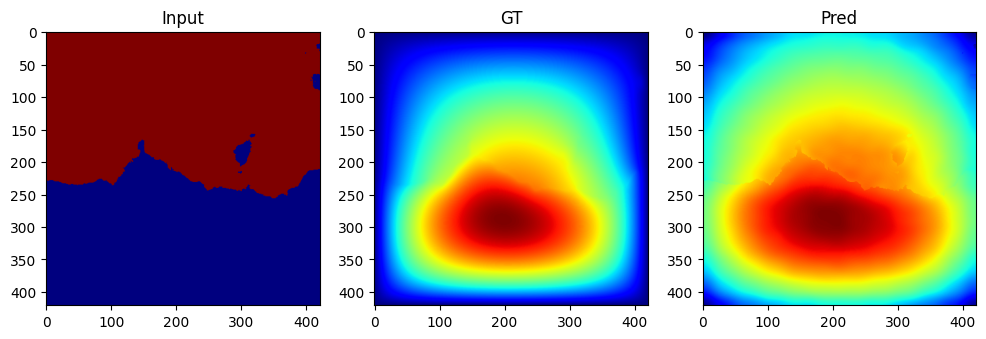

In [7]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import opendatasets as od
from torch.utils.data import DataLoader, TensorDataset
from scipy.io import loadmat
from tqdm import tqdm

os.environ['KAGGLE_USERNAME'] = "your username here"
os.environ['KAGGLE_KEY'] = "your key here"

dataset_url = "https://www.kaggle.com/datasets/scaomath/pde-dataset"
od.download(dataset_url)

def get_best_file(root_dir):
    targets = ["piececonst_r421_N1024_smooth1.mat", "burgers_data_R10.mat"]
    for target in targets:
        for root, _, files in os.walk(root_dir):
            if target in files: return os.path.join(root, target)
    return None

data_path = get_best_file("./pde-dataset")

def load_subset(path, n_samples=100):
    raw = loadmat(path)
    if 'coeff' in raw:
        X, Y = raw['coeff'], raw['sol']
    else:
        keys = [k for k in raw.keys() if not k.startswith('__')]
        X, Y = raw[keys[0]], raw[keys[1]]

    X = torch.tensor(X[:n_samples], dtype=torch.float32).unsqueeze(-1)
    Y = torch.tensor(Y[:n_samples], dtype=torch.float32).unsqueeze(-1)
    return X, Y

X_sub, Y_sub = load_subset(data_path, n_samples=100)
train_loader = DataLoader(TensorDataset(X_sub, Y_sub), batch_size=10, shuffle=True)

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels, self.out_channels = in_channels, out_channels
        self.modes1, self.modes2 = modes1, modes2
        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = torch.einsum("bixy,ioxy->boxy", x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = torch.einsum("bixy,ioxy->boxy", x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

class FNO2d(nn.Module):
    def __init__(self, modes1, modes2, width):
        super().__init__()
        self.fc0 = nn.Linear(3, width)
        self.convs = nn.ModuleList([SpectralConv2d(width, width, modes1, modes2) for _ in range(4)])
        self.ws = nn.ModuleList([nn.Conv2d(width, width, 1) for _ in range(4)])
        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        b, res_x, res_y = x.shape[0], x.shape[1], x.shape[2]
        grid = torch.stack(torch.meshgrid(torch.linspace(0,1,res_x), torch.linspace(0,1,res_y), indexing='ij'), dim=-1)
        grid = grid.unsqueeze(0).repeat(b,1,1,1).to(x.device)

        x = torch.cat((x, grid), dim=-1)
        x = self.fc0(x).permute(0, 3, 1, 2)
        for conv, w in zip(self.convs, self.ws):
            x = F.gelu(conv(x) + w(x))
        x = x.permute(0, 2, 3, 1)
        return self.fc2(F.gelu(self.fc1(x)))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FNO2d(12, 12, 32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"\n Testing FNO with {len(X_sub)} samples ")
for epoch in range(15):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = torch.mean((out.view(x.size(0), -1) - y.view(y.size(0), -1))**2) / (torch.mean(y.view(y.size(0), -1)**2) + 1e-8)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1} | Relative Loss: {loss.item():.4f}")

torch.save(model.state_dict(), "fno_test_subset.pth")
print("\nModel saved as fno_test_subset.pth")

with torch.no_grad():
    test_in = X_sub[0:1].to(device)
    test_gt = Y_sub[0:1]
    test_pred = model(test_in).cpu()

plt.figure(figsize=(12, 4))
plt.subplot(1,3,1); plt.imshow(test_in[0,...,0].cpu(), cmap='jet'); plt.title("Input")
plt.subplot(1,3,2); plt.imshow(test_gt[0,...,0], cmap='jet'); plt.title("GT")
plt.subplot(1,3,3); plt.imshow(test_pred[0,...,0], cmap='jet'); plt.title("Pred")
plt.show()

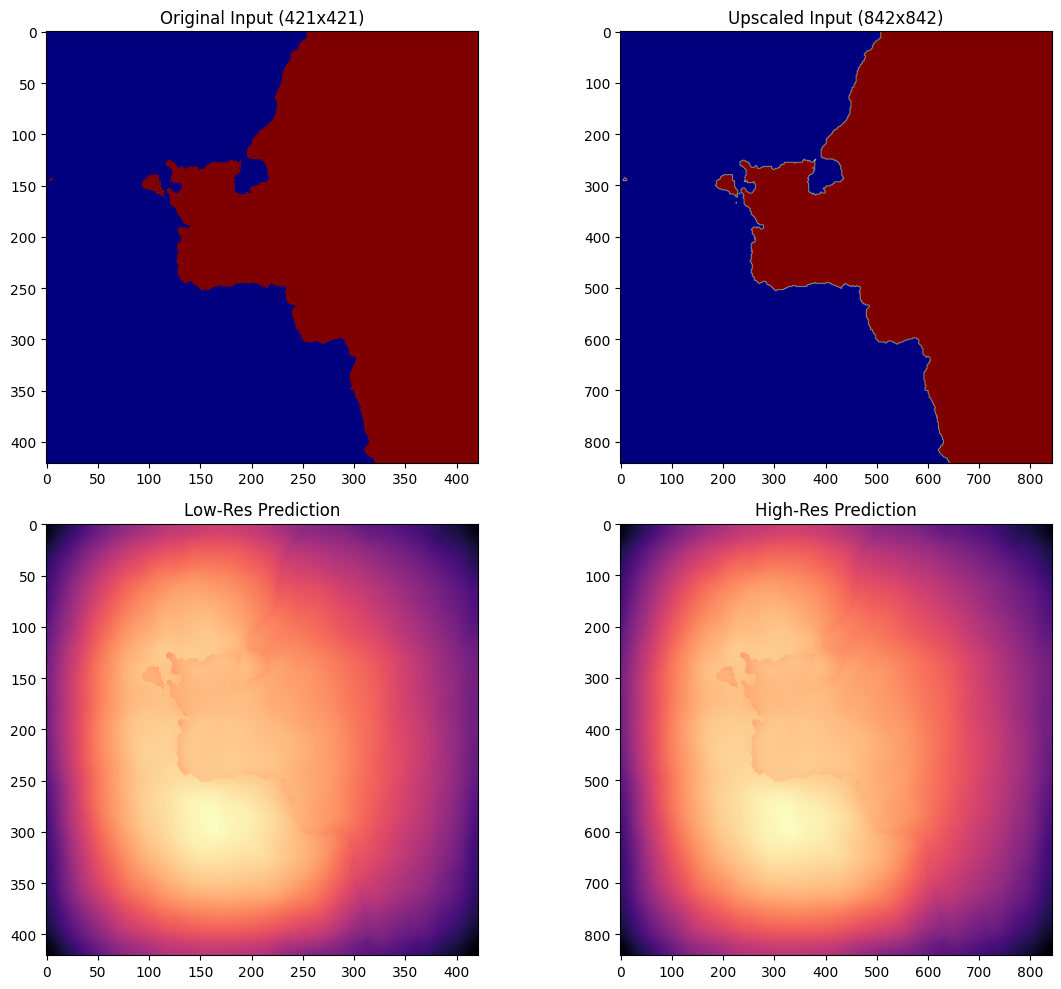

Low-Res Output Max: 0.0118
High-Res Output Max: 0.0117


In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():

    low_res_input = X_sub[10:11].to(device)


    hi_res_input = F.interpolate(
        low_res_input.permute(0, 3, 1, 2),
        size=(842, 842),
        mode='bilinear',
        align_corners=True
    ).permute(0, 2, 3, 1)

    low_res_pred = model(low_res_input)
    hi_res_pred = model(hi_res_input)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].imshow(low_res_input[0, ..., 0].cpu(), cmap='jet')
ax[0, 0].set_title("Original Input (421x421)")
ax[0, 1].imshow(hi_res_input[0, ..., 0].cpu(), cmap='jet')
ax[0, 1].set_title("Upscaled Input (842x842)")

ax[1, 0].imshow(low_res_pred[0, ..., 0].cpu(), cmap='magma')
ax[1, 0].set_title("Low-Res Prediction")
ax[1, 1].imshow(hi_res_pred[0, ..., 0].cpu(), cmap='magma')
ax[1, 1].set_title("High-Res Prediction")

plt.tight_layout()
plt.show()

print(f"Low-Res Output Max: {low_res_pred.max().item():.4f}")
print(f"High-Res Output Max: {hi_res_pred.max().item():.4f}")